Starting Anomaly Detection project...
Generated 220 data points (200 normal, 20 anomalous).
Training Isolation Forest model...
Prediction complete.
Model found 2 errors.
Accuracy: 99.09%

Model predicted 22 anomalies.
There were actually 20 anomalies.
Generating visualization...


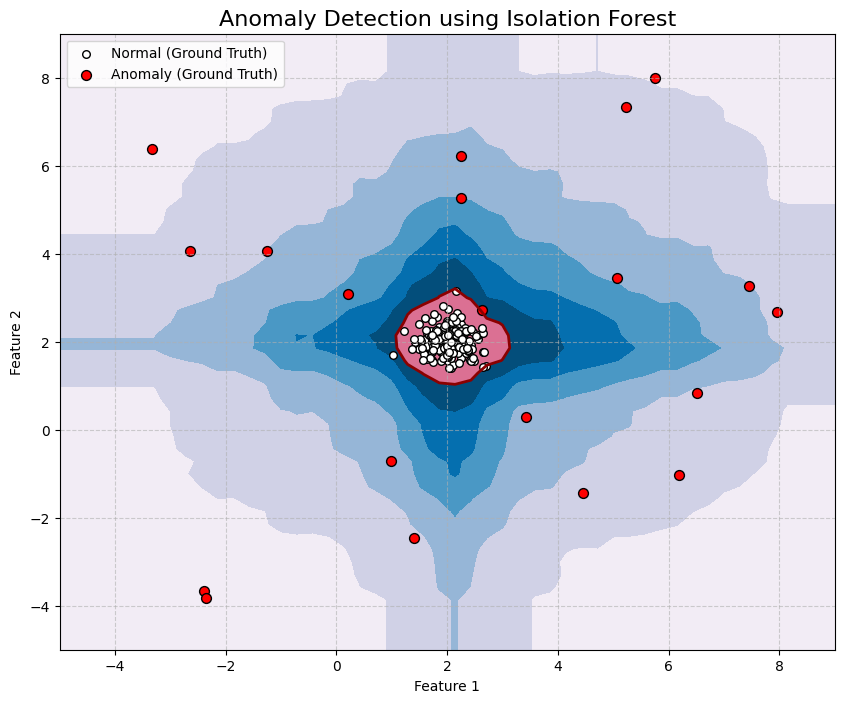

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

print("Starting Anomaly Detection project...")

# --- 1. Data Generation ---
# We will create a synthetic dataset to clearly show how anomaly detection works.

# Set a random seed for reproducibility
np.random.seed(42)

# Generate 'normal' data: 200 points in a tight cluster (a 2D Gaussian distribution)
X_normal = 0.3 * np.random.randn(200, 2) + np.array([2, 2])

# Generate 'anomalous' data: 20 points scattered far away
X_anomalies = np.random.uniform(low=-4, high=8, size=(20, 2))

# Combine the normal and anomalous data into one dataset
# X will be our feature set (the data points)
X = np.r_[X_normal, X_anomalies]

# y will be our ground truth labels (1 for normal, -1 for anomaly)
# This is just for visualization/evaluation. The model itself is unsupervised.
y = np.array([1] * 200 + [-1] * 20)

print(f"Generated {len(X)} data points ({len(X_normal)} normal, {len(X_anomalies)} anomalous).")


# --- 2. Model Definition & Training ---
# We will use an Isolation Forest.
# 'contamination' is the expected proportion of anomalies in the data.
# We set it to 0.1 because we know 20 out of 220 points (approx 9%) are anomalies.
# In a real-world scenario, you might have to estimate this value.
clf = IsolationForest(contamination=0.1, random_state=42)

print("Training Isolation Forest model...")
# Train the model. Isolation Forest is unsupervised, so it doesn't need labels (y).
clf.fit(X)

# --- 3. Prediction ---
# Now, let's have the model predict which points are anomalies.
# It will return 1 for inliers (normal) and -1 for outliers (anomalies).
y_pred = clf.predict(X)

# Calculate the decision scores. Negative scores indicate anomalies.
scores = clf.decision_function(X)

print("Prediction complete.")

# --- 4. Analysis & Results ---
n_errors = (y_pred != y).sum()
accuracy = 100 * (1 - (n_errors / len(y)))

print(f"Model found {n_errors} errors.")
print(f"Accuracy: {accuracy:.2f}%")

# Find the indices of the points our model predicted as anomalies
predicted_anomalies = np.where(y_pred == -1)[0]
actual_anomalies = np.where(y == -1)[0]

print(f"\nModel predicted {len(predicted_anomalies)} anomalies.")
print(f"There were actually {len(actual_anomalies)} anomalies.")


# --- 5. Visualization ---
print("Generating visualization...")

# Create a meshgrid to plot the decision boundary
xx, yy = np.meshgrid(np.linspace(-5, 9, 50), np.linspace(-5, 9, 50))
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.title("Anomaly Detection using Isolation Forest", fontsize=16)

# Plot the decision boundary contour
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7), cmap=plt.cm.PuBu)
a = plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='darkred')
plt.contourf(xx, yy, Z, levels=[0, Z.max()], colors='palevioletred')

# Plot the 'normal' data points (ground truth)
plt.scatter(X_normal[:, 0], X_normal[:, 1], c='white', s=30, edgecolor='k', label='Normal (Ground Truth)')

# Plot the 'anomalous' data points (ground truth)
plt.scatter(X_anomalies[:, 0], X_anomalies[:, 1], c='red', s=50, edgecolor='k', label='Anomaly (Ground Truth)')

# Add a legend
plt.legend(loc='upper left')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis('tight')
plt.grid(True, linestyle='--', alpha=0.6)

# Save the plot to a file
plt.savefig("anomaly_detection_plot.png")


# Show the plot
plt.show()
